# **Projeto de Graduação em Computação II [2026-Q1]**

Universidade Federal do ABC

Orientador Carlos da Silva dos Santos

### **EQUIPE**

---

Caio Cardoso Dos Santos - RA: 11202021632

Victor Ravazio de Lima - RA: 11201920941

### **IMPLEMENTAÇÃO**
---

In [165]:
# modulo para importar dataset a partir de um link
!pip install gdown

In [166]:
!pip install emoji

In [167]:
#Bibliotecas
import pandas as pd
import numpy as np
import json
from datetime import datetime
from google.colab import files
import gdown
import matplotlib.pyplot as plt


In [168]:
# baixando dataset para o collab
import gdown

file_id = "1EtsrGSyFx26nYa3d_Yb9m39ta0y1WmBh"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "mandetta.json", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1EtsrGSyFx26nYa3d_Yb9m39ta0y1WmBh
From (redirected): https://drive.google.com/uc?id=1EtsrGSyFx26nYa3d_Yb9m39ta0y1WmBh&confirm=t&uuid=0a33b7d8-444f-41ec-9029-471c0d1b3afc
To: /content/mandetta.json
100%|██████████| 1.84G/1.84G [00:42<00:00, 43.9MB/s]


'mandetta.json'

In [169]:
#obtendo o caminho do dataset
file_path = "mandetta.json"


In [170]:
#importando e manipulando o dataset em json Lines (cada linha deste "json" é um "json")

data = [] #lista de jsons - basicamente um dicionario
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line)) #converte o Json em dicionario e adiciona a lista "data"

In [171]:
#extraindo texto completo
def extract_full_text(tweet_obj):
    # Caso truncado
    if tweet_obj.get("truncated"):
        # Se existe versão completa
        if "extended_tweet" in tweet_obj and "full_text" in tweet_obj["extended_tweet"]:
            return tweet_obj["extended_tweet"]["full_text"]
        else:
            # se for truncado e não existir o "full_text", retorna none
            return None
    else:
        return tweet_obj.get("text", "")

In [172]:
def has_image(tweet_obj):
    # checa o próprio tweet
    if "extended_entities" in tweet_obj:
        media = tweet_obj["extended_entities"].get("media", [])
        if any(m.get("type") == "photo" for m in media):
            return True

    #Resolvendo o "problema" - extended entities pode estar em "extended_tweet" e não no tweet base
    if "extended_tweet" in tweet_obj:
        if "extended_entities" in tweet_obj["extended_tweet"]:
            media = tweet_obj["extended_tweet"]["extended_entities"].get("media", [])
            if any(m.get("type") == "photo" for m in media):
                return True

    # checa quote (se existir)
    if tweet_obj.get("is_quote_status") and "quoted_status" in tweet_obj:
        quoted = tweet_obj["quoted_status"]
        if "extended_entities" in quoted:
            media = quoted["extended_entities"].get("media", [])
            if any(m.get("type") == "photo" for m in media):
                return True

    return False

In [173]:
#Construindo lista estruturada
processed = [] #lista de dicionarios (cada tweet é um dicionario - no fim é facil converter dicionario num df)

for tweet in data: #data é uma lista de dicionarios e tweet itera dicionario em dicionario em data

    # Identificando se é retweet
    if "retweeted_status" in tweet:
        base_tweet = tweet["retweeted_status"] #retweeted_status é um subdicionario dentro do dicionario tweets - contem as infos do retweet como texto, autor e etc
        is_retweet = True

        original_tweet_date = base_tweet.get("created_at")
        retweeter_id = tweet.get("user", {}).get("id_str")
        retweet_date = tweet.get("created_at")

    #Caso contrario, é um tweet original
    else:
        base_tweet = tweet
        is_retweet = False

        original_tweet_date = tweet.get("created_at")
        retweeter_id = None
        retweet_date = None

    #verificando se existe imagem (caso sim, desconsiderar o tweet)
    if has_image(base_tweet):
      continue

    # Tratando quotes (respostas)
    is_quote = base_tweet.get("is_quote_status", False) #verificando se é um quote

    if is_quote and "quoted_status" in base_tweet: #se for quote e o campo quote_status (dicionario de elementos, igual retweet status) não for null
        quoted_tweet = base_tweet["quoted_status"] #quoted_status é um subdicionario dentro do dicionario tweets - contem as infos do quote como texto, autor e etc

        quoted_text = extract_full_text(quoted_tweet)
        quoted_tweet_id = quoted_tweet.get("id_str")
        quoted_user_id = quoted_tweet.get("user", {}).get("id_str")
    else:
        quoted_text = None
        quoted_tweet_id = None
        quoted_user_id = None


    #Tratando reply
    is_reply = base_tweet.get("in_reply_to_status_id", False) is not None

    reply_to_tweet_id = base_tweet.get("in_reply_to_status_id_str")
    reply_to_user_id = base_tweet.get("in_reply_to_user_id_str")
    reply_to_screen_name = base_tweet.get("in_reply_to_screen_name")

    #Produzindo o dicionario do tweet e adicionando na lista
    text = extract_full_text(base_tweet)

    # Se text retorna null, descartar
    if text is None:
      continue

    processed.append({
        "tweet_id": base_tweet.get("id_str"),
        "user_id_original": base_tweet.get("user", {}).get("id_str"),
        "text": text,
        "created_at_original": original_tweet_date,

        "retweet_count": base_tweet.get("retweet_count", 0),
        "like_count": base_tweet.get("favorite_count", 0),

        # retweet info
        "is_retweet": is_retweet,
        "retweeter_user_id": retweeter_id,
        "retweet_created_at": retweet_date,

        # quote info
        "is_quote": is_quote,
        "quoted_tweet_id": quoted_tweet_id,
        "quoted_user_id": quoted_user_id,
        "quoted_text": quoted_text,

        # --- REPLY ---
        "is_reply": is_reply,
        "reply_to_tweet_id": reply_to_tweet_id,
        "reply_to_user_id": reply_to_user_id,
        "reply_to_screen_name": reply_to_screen_name
    })

In [174]:
#Criando DataFrame

df = pd.DataFrame(processed)

df
#print(df.shape)

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name
0,1250828250370183168,57664074,"Para quem defendia o Mandetta , agora já sabe ...",Thu Apr 16 16:47:48 +0000 2020,0,0,False,None,None,False,None,None,None,False,None,None,None
1,1250828253260132353,882627779363254274,que merdaaaaaaaaaaaaaa tiraram o mandetta véi,Thu Apr 16 16:47:49 +0000 2020,0,0,False,None,None,False,None,None,None,False,None,None,None
2,1250827965899984907,1164652265271189510,#estudioi\nMandetta estava usando Bolsonaro co...,Thu Apr 16 16:46:40 +0000 2020,1,1,True,961953706328641536,Thu Apr 16 16:47:49 +0000 2020,False,None,None,None,False,None,None,None
3,1250780916575866881,1138847289978626049,"Dória, Witzel, Alcolumbre, Rodrigo Maia, Mande...",Thu Apr 16 13:39:43 +0000 2020,751,2333,True,1656290641,Thu Apr 16 16:47:49 +0000 2020,False,None,None,None,False,None,None,None
4,1250828255806009345,1039608133587554311,"@conexaopolitica Demorou, não deveria ne ter s...",Thu Apr 16 16:47:50 +0000 2020,0,0,False,None,None,False,None,None,None,True,1250553117378088961,1523748277,conexaopolitica
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263534,1251134636043972608,835570202289012736,"O Mandetta é o maior ortopetista do Brasil, co...",Fri Apr 17 13:05:16 +0000 2020,607,3101,True,1049836375053402113,Fri Apr 17 17:01:16 +0000 2020,False,None,None,None,False,None,None,None
263535,1251194027124408328,52720920,"@gilebruno Pra eles pode tudo Gil, só não pode...",Fri Apr 17 17:01:16 +0000 2020,0,0,False,None,None,False,None,None,None,True,1251191015479926785,62290997,gilebruno
263536,1251162425610526720,1004511711251099653,Bolsonaro acabou de demitir o Presidente do CN...,Fri Apr 17 14:55:42 +0000 2020,1053,2524,True,51916363,Fri Apr 17 17:01:16 +0000 2020,False,None,None,None,False,None,None,None
263537,1250878161363046402,354095556,"Em sua despedida, Mandetta defende a vida, o S...",Thu Apr 16 20:06:08 +0000 2020,20159,112966,False,None,None,False,None,None,None,False,None,None,None


In [175]:
# Buscando textos originais dos replys - O texto original (que esta sendo respondido) não está no tweet que esta respondendo: ideia buscar neste dataset pelo id neste dataset
# garantindo ids em strings
df["tweet_id"] = df["tweet_id"].astype(str)
df["reply_to_tweet_id"] = df["reply_to_tweet_id"].astype(str)

# criar dicionário id -> texto
id_to_text = dict(zip(df["tweet_id"], df["text"])) # Organizando o dataset num dicionario: Chave: tweet id, conteudo: texto - isso facilita a busca (ex: ao fornecer a chave X, retorna seu texto Y)

# Criando reply text: Basicamente varre cada reply_tweet_id do df, e se não for none, aplica no dicionario, ou seja, busca no dicionario aquele tweet id do reply como chave - se encontrar, retorna o conteudo, se não, none
df["reply_text"] = df["reply_to_tweet_id"].map(id_to_text)

In [176]:
#Removendo URLs
import re
import emoji

def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = emoji.replace_emoji(text, replace='')
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"RT\s+", "", text)
    text = re.sub(r"\n", " ", text)
    return text.strip()

df["text"] = df["text"].apply(clean_text)
df["quoted_text"] = df["quoted_text"].apply(clean_text)
df["reply_text"] = df["reply_text"].apply(clean_text)

In [177]:
#removendo textos vazios
df = df[df["text"].notnull()]
df = df[df["text"].str.strip() != ""]
print(df.shape)

(263539, 18)


In [178]:
#replys "usáveis" - Antes de remover duplicatas
replys = df.loc[(df["is_reply"] == True) & (df["reply_text"].str.strip() != "")]

In [179]:
replys

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
4,1250828255806009345,1039608133587554311,"Demorou, não deveria ne ter sido nomeado mande...",Thu Apr 16 16:47:50 +0000 2020,0,0,False,None,None,False,None,None,,True,1250553117378088961,1523748277,conexaopolitica,"“O dia que ele [Mandetta] sair, eu saio junto ..."
13,1250828263976558593,170400715,"Como uma cobra ratoeira, está o senhor senador...",Thu Apr 16 16:47:52 +0000 2020,0,0,False,None,None,False,None,None,,True,1250796092092006401,73745956,alvarodias_,A maioria esmagadora dos brasileiros é contrár...
18,1250821578318897156,35219319,#ForaMandettaTraira Eu não fui entrevistada!...,Thu Apr 16 16:21:18 +0000 2020,12,23,True,3127892382,Thu Apr 16 16:47:55 +0000 2020,False,None,None,,True,1250796092092006401,73745956,alvarodias_,A maioria esmagadora dos brasileiros é contrár...
36,1250828326454923267,1095129896630841345,Mandetta é um TRAIDOR!!!! #ForaMandettaUrgente,Thu Apr 16 16:48:06 +0000 2020,0,0,False,None,None,False,None,None,,True,1250782520930598912,33520195,Rconstantino,Mandetta e sua política de isolamento estão lo...
130,1250828470004957186,1244304665317179398,"Mandetta, ficou deslumbrado ao microfone e o t...",Thu Apr 16 16:48:41 +0000 2020,0,0,False,None,None,False,None,None,,True,1250737690879893505,2880932962,o_antagonista,Demissão de Mandetta é rejeitada por 76% dos b...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263419,1251183729441214464,30752253,"Cadê a máscara e distanciamento, Mandetta ? Ah...",Fri Apr 17 16:20:21 +0000 2020,0,0,False,None,None,False,None,None,,True,1251147808209420290,204368952,laurojardim,Mandetta deixa ministério cantando.
263427,1251183734587633665,917045970931798016,Como sou uma senhora fina não vou escrever o q...,Fri Apr 17 16:20:22 +0000 2020,0,0,False,None,None,False,None,None,,True,1250907090698280963,40095953,SenadoFederal,Senadores se manifestam sobre demissão de Mand...
263430,1250952649056403457,1171843460967665669,Apesar dos elogios por parte da mídia e da opi...,Fri Apr 17 01:02:07 +0000 2020,7,14,True,39990331,Fri Apr 17 16:20:23 +0000 2020,True,1243930849118007298,1171843460967665669,#MaisLidaDaSemana | A mudança de postura do mi...,True,1250950799980724224,1171843460967665669,RevistaBadaro,Rumores da saída de Luiz Henrique Mandetta for...
263501,1251193985634353154,1230272598480760834,"O ex Ministro da Saúde, Luiz Henrique Mandett...",Fri Apr 17 17:01:06 +0000 2020,0,0,False,None,None,False,None,None,,True,1251175228992114689,106175018,JovemPanNews,"O ex-ministro da saúde, Luiz Henrique Mandetta..."


In [180]:
#quotes - Antes de remover duplicatas

quotes = df.loc[(df["is_quote"] == True) & (df["quoted_text"].str.strip() != "")]
quotes

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
9,1250828262059761664,160722408,Muita Tristeza !!! Muita !!!,Thu Apr 16 16:47:51 +0000 2020,0,0,False,None,None,True,1250818472944287744,1109234347771613185,"Segundo o leitor(sic), Mandetta informou aos a...",False,None,None,None,
17,1250828274525245441,1508531576,Nata azeda. #ForaMandettaUrgente,Thu Apr 16 16:47:54 +0000 2020,0,0,False,None,None,True,1250654343457636352,61251074,"A Pepa quer a permanência de Mandetta. Pepa, M...",False,None,None,None,
23,1250828291512156161,3313618782,"""O ministro da Saúde, Luiz Henrique Mandetta d...",Thu Apr 16 16:47:58 +0000 2020,0,0,False,None,None,True,1250827329817006081,20766595,"O ministro da Saúde, Luiz Henrique Mandetta di...",False,None,None,None,
24,1250828291688345600,1081020435037335558,Roque ou Liminha,Thu Apr 16 16:47:58 +0000 2020,0,0,False,None,None,True,1250817060294270976,28407958,Sílvio Santos também indica nome a Bolsonaro p...,False,None,None,None,
29,1250828305848205313,3433331123,Ele vai trabalhar em novela da Globo.,Thu Apr 16 16:48:02 +0000 2020,0,0,False,None,None,True,1250737690879893505,2880932962,Demissão de Mandetta é rejeitada por 76% dos b...,False,None,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263519,1251169671660871681,735741240,Distanciamento social no ** dos outros é refre...,Fri Apr 17 15:24:29 +0000 2020,591,2272,True,766996364,Fri Apr 17 17:01:13 +0000 2020,True,1251147808209420290,204368952,Mandetta deixa ministério cantando.,False,None,None,None,
263523,1251182339155206144,755920276257382404,Quantas recomendações do Ministério da Saúde f...,Fri Apr 17 16:14:50 +0000 2020,1,6,True,4163376077,Fri Apr 17 17:01:14 +0000 2020,True,1251147808209420290,204368952,Mandetta deixa ministério cantando.,False,None,None,None,
263524,1251169671660871681,735741240,Distanciamento social no ** dos outros é refre...,Fri Apr 17 15:24:29 +0000 2020,592,2273,True,1135551545238536192,Fri Apr 17 17:01:14 +0000 2020,True,1251147808209420290,204368952,Mandetta deixa ministério cantando.,False,None,None,None,
263525,1251161749761306631,50704902,"A preocupação com o contágio é notável. Ah, se...",Fri Apr 17 14:53:01 +0000 2020,668,2693,True,141041366,Fri Apr 17 17:01:14 +0000 2020,True,1251147808209420290,204368952,Mandetta deixa ministério cantando.,False,None,None,None,


In [181]:
#genéricos - Antes de remover duplicatas

generics = df.loc[(df["is_quote"] == False) & (df["is_reply"] == False)]
generics

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
0,1250828250370183168,57664074,"Para quem defendia o Mandetta , agora já sabe ...",Thu Apr 16 16:47:48 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
1,1250828253260132353,882627779363254274,que merdaaaaaaaaaaaaaa tiraram o mandetta véi,Thu Apr 16 16:47:49 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
2,1250827965899984907,1164652265271189510,#estudioi Mandetta estava usando Bolsonaro com...,Thu Apr 16 16:46:40 +0000 2020,1,1,True,961953706328641536,Thu Apr 16 16:47:49 +0000 2020,False,None,None,,False,None,None,None,
3,1250780916575866881,1138847289978626049,"Dória, Witzel, Alcolumbre, Rodrigo Maia, Mande...",Thu Apr 16 13:39:43 +0000 2020,751,2333,True,1656290641,Thu Apr 16 16:47:49 +0000 2020,False,None,None,,False,None,None,None,
5,1250817185154510848,1045860705130467328,"Falaram hoje que, trocar o MANDETTA por outro ...",Thu Apr 16 16:03:50 +0000 2020,3,4,True,872937321745850368,Thu Apr 16 16:47:50 +0000 2020,False,None,None,,False,None,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263533,1251151454770872321,36489269,Assisti a cerimônia de despedida do Ministro M...,Fri Apr 17 14:12:06 +0000 2020,32,258,True,45881652,Fri Apr 17 17:01:16 +0000 2020,False,None,None,,False,None,None,None,
263534,1251134636043972608,835570202289012736,"O Mandetta é o maior ortopetista do Brasil, co...",Fri Apr 17 13:05:16 +0000 2020,607,3101,True,1049836375053402113,Fri Apr 17 17:01:16 +0000 2020,False,None,None,,False,None,None,None,
263536,1251162425610526720,1004511711251099653,Bolsonaro acabou de demitir o Presidente do CN...,Fri Apr 17 14:55:42 +0000 2020,1053,2524,True,51916363,Fri Apr 17 17:01:16 +0000 2020,False,None,None,,False,None,None,None,
263537,1250878161363046402,354095556,"Em sua despedida, Mandetta defende a vida, o S...",Thu Apr 16 20:06:08 +0000 2020,20159,112966,False,None,None,False,None,None,,False,None,None,None,


In [182]:
#tamanho do df
num_tweets = len(df)
print(f"O DataFrame contém {num_tweets} tweets no total.")

O DataFrame contém 263539 tweets no total.


In [183]:
#quantidade de retweets
num_rt = df[df['is_retweet'] == True].shape[0]
print(f"O DataFrame contém {num_rt} retweets.")

O DataFrame contém 199468 retweets.


In [184]:
#quantidade de Tweets originais (não são retweets)
num_tweets_or = df[df['is_retweet'] == False].shape[0]
print(f"O DataFrame contém {num_tweets_or} tweets originais (tweets que não são retweets).")

O DataFrame contém 64071 tweets originais (tweets que não são retweets).


In [185]:
#Quantidade de duplicatas
df_copy = df.copy()
duplicados = df_copy[df_copy.duplicated(subset='text', keep='first')]
duplicados

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
20,1250814463911104517,225925013,"Excelente, Presidente . Convém lembrarmos que...",Thu Apr 16 15:53:01 +0000 2020,731,2765,True,755120608158023680,Thu Apr 16 16:47:57 +0000 2020,False,None,None,,False,None,None,None,
21,1250782520930598912,33520195,Mandetta e sua política de isolamento estão lo...,Thu Apr 16 13:46:06 +0000 2020,1428,5885,True,1663076430,Thu Apr 16 16:47:57 +0000 2020,False,None,None,,False,None,None,None,
27,1250827836174237698,330770436,"Enquanto falta remédio no posto de saúde, e o ...",Thu Apr 16 16:46:10 +0000 2020,14,27,True,2172828447,Thu Apr 16 16:47:59 +0000 2020,False,None,None,,False,None,None,None,
30,1250827836174237698,330770436,"Enquanto falta remédio no posto de saúde, e o ...",Thu Apr 16 16:46:10 +0000 2020,15,28,True,1102702616302239744,Thu Apr 16 16:48:02 +0000 2020,False,None,None,,False,None,None,None,
37,1250814463911104517,225925013,"Excelente, Presidente . Convém lembrarmos que...",Thu Apr 16 15:53:01 +0000 2020,732,2771,True,97965159,Thu Apr 16 16:48:07 +0000 2020,False,None,None,,False,None,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263531,1251128075355672578,1138847289978626049,Já tem demista afirmando que Mandetta hoje é m...,Fri Apr 17 12:39:12 +0000 2020,285,1621,True,3373314207,Fri Apr 17 17:01:15 +0000 2020,False,None,None,,False,None,None,None,
263533,1251151454770872321,36489269,Assisti a cerimônia de despedida do Ministro M...,Fri Apr 17 14:12:06 +0000 2020,32,258,True,45881652,Fri Apr 17 17:01:16 +0000 2020,False,None,None,,False,None,None,None,
263534,1251134636043972608,835570202289012736,"O Mandetta é o maior ortopetista do Brasil, co...",Fri Apr 17 13:05:16 +0000 2020,607,3101,True,1049836375053402113,Fri Apr 17 17:01:16 +0000 2020,False,None,None,,False,None,None,None,
263536,1251162425610526720,1004511711251099653,Bolsonaro acabou de demitir o Presidente do CN...,Fri Apr 17 14:55:42 +0000 2020,1053,2524,True,51916363,Fri Apr 17 17:01:16 +0000 2020,False,None,None,,False,None,None,None,


In [186]:
#tweets originais duplicados
orig_dup = duplicados[duplicados['is_retweet'] == False]
orig_dup

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
88,1250828399783936000,1241085987184312321,#STFVergonhaNacional #AbortoNao MANDETTA CAN...,Thu Apr 16 16:48:24 +0000 2020,0,0,False,None,None,True,1250546585613852676,2356746018,Surreal! A corte das trevas tá se aproveitando...,False,None,None,None,
133,1250828477563011074,1241085987184312321,#STFVergonhaNacional #AbortoNao MANDETTA CAN...,Thu Apr 16 16:48:42 +0000 2020,0,0,False,None,None,True,1250600002935816192,36714942,Em meio à pandemia e palavras de todos em preo...,False,None,None,None,
165,1250828528851079168,1241085987184312321,#STFVergonhaNacional #AbortoNao MANDETTA CAN...,Thu Apr 16 16:48:55 +0000 2020,0,0,False,None,None,True,1250810706435375105,74756085,Calendário de pagamento do coronavoucher de R$...,False,None,None,None,
169,1250828534429429760,981338375268585473,São Mandetta via,Thu Apr 16 16:48:56 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
212,1250828623612981250,74137088,Mandetta é um ENGANADOR. Já devia ter sido DEM...,Thu Apr 16 16:49:17 +0000 2020,0,0,False,None,None,False,None,None,,True,1250818472944287744,1109234347771613185,RizethJ,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263261,1251183523203035138,1169222731835084802,"Gozado! Agora que o super Mandetta, não é mais...",Fri Apr 17 16:19:32 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
263408,1251183719307771904,66866450,"Agora que o super Mandetta, não é mais ministr...",Fri Apr 17 16:20:19 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
263444,1251183757643714561,68705985,"Mandetta era um lixo, corrupto, ignorante, des...",Fri Apr 17 16:20:28 +0000 2020,0,0,False,None,None,False,None,None,,True,1251178823703506947,1037152208754823168,FabioTalhari,
263530,1251194022384873478,2235327544,"Os bastidores da ""briga"" entre Bolsonaro e Man...",Fri Apr 17 17:01:15 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,


In [187]:
#numero liquido de tweets
num_liq = num_tweets - len(duplicados)
print(f"O DataFrame contém {num_liq} tweets usáveis.")

O DataFrame contém 66236 tweets usáveis.


In [188]:
#verificando retweets iguais
retweets = df.loc[df['is_retweet'] == True].copy()

retweets_iguais = retweets[retweets.duplicated(subset='text', keep='first')]

retweets_iguais

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
20,1250814463911104517,225925013,"Excelente, Presidente . Convém lembrarmos que...",Thu Apr 16 15:53:01 +0000 2020,731,2765,True,755120608158023680,Thu Apr 16 16:47:57 +0000 2020,False,None,None,,False,None,None,None,
21,1250782520930598912,33520195,Mandetta e sua política de isolamento estão lo...,Thu Apr 16 13:46:06 +0000 2020,1428,5885,True,1663076430,Thu Apr 16 16:47:57 +0000 2020,False,None,None,,False,None,None,None,
27,1250827836174237698,330770436,"Enquanto falta remédio no posto de saúde, e o ...",Thu Apr 16 16:46:10 +0000 2020,14,27,True,2172828447,Thu Apr 16 16:47:59 +0000 2020,False,None,None,,False,None,None,None,
30,1250827836174237698,330770436,"Enquanto falta remédio no posto de saúde, e o ...",Thu Apr 16 16:46:10 +0000 2020,15,28,True,1102702616302239744,Thu Apr 16 16:48:02 +0000 2020,False,None,None,,False,None,None,None,
37,1250814463911104517,225925013,"Excelente, Presidente . Convém lembrarmos que...",Thu Apr 16 15:53:01 +0000 2020,732,2771,True,97965159,Thu Apr 16 16:48:07 +0000 2020,False,None,None,,False,None,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263529,1251119683656351745,33520195,"Mandetta é do DEM, adorado por Maia, que acha ...",Fri Apr 17 12:05:51 +0000 2020,2660,13956,True,223474258,Fri Apr 17 17:01:15 +0000 2020,False,None,None,,False,None,None,None,
263531,1251128075355672578,1138847289978626049,Já tem demista afirmando que Mandetta hoje é m...,Fri Apr 17 12:39:12 +0000 2020,285,1621,True,3373314207,Fri Apr 17 17:01:15 +0000 2020,False,None,None,,False,None,None,None,
263533,1251151454770872321,36489269,Assisti a cerimônia de despedida do Ministro M...,Fri Apr 17 14:12:06 +0000 2020,32,258,True,45881652,Fri Apr 17 17:01:16 +0000 2020,False,None,None,,False,None,None,None,
263534,1251134636043972608,835570202289012736,"O Mandetta é o maior ortopetista do Brasil, co...",Fri Apr 17 13:05:16 +0000 2020,607,3101,True,1049836375053402113,Fri Apr 17 17:01:16 +0000 2020,False,None,None,,False,None,None,None,


In [189]:
contagem_df = retweets_iguais['text'].value_counts().reset_index()
contagem_df

,text,count
0,Caralho to indignado que o Mandetta saiu antes...,8340
1,"Em sua despedida, Mandetta defende a vida, o S...",7789
2,"AÍ MANDETTA, LIBERA OS RESULTADOS DOS EXAMES D...",7599
3,O elogio emocionado de Fernando Haddad a Henri...,6467
4,Mandetta era um dos poucos desse governo que e...,3476
...,...,...
5853,Incrível a demência desse povo. Tá vendo o pre...,1
5854,"Desde que foi nomeado, já saíram falando que e...",1
5855,"“A vida é o mais importante, mas...”",1
5856,"Ele pode abraçar?!?!?! Só ele?!?!?!? Taí, gent...",1


In [190]:
num_copias = int(contagem_df["count"].sum())
num_copias

186318

In [191]:
#removendo duplicatas
df = df.drop_duplicates(subset=["text"])
print(df.shape)

(66236, 18)


In [192]:
df

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
0,1250828250370183168,57664074,"Para quem defendia o Mandetta , agora já sabe ...",Thu Apr 16 16:47:48 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
1,1250828253260132353,882627779363254274,que merdaaaaaaaaaaaaaa tiraram o mandetta véi,Thu Apr 16 16:47:49 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
2,1250827965899984907,1164652265271189510,#estudioi Mandetta estava usando Bolsonaro com...,Thu Apr 16 16:46:40 +0000 2020,1,1,True,961953706328641536,Thu Apr 16 16:47:49 +0000 2020,False,None,None,,False,None,None,None,
3,1250780916575866881,1138847289978626049,"Dória, Witzel, Alcolumbre, Rodrigo Maia, Mande...",Thu Apr 16 13:39:43 +0000 2020,751,2333,True,1656290641,Thu Apr 16 16:47:49 +0000 2020,False,None,None,,False,None,None,None,
4,1250828255806009345,1039608133587554311,"Demorou, não deveria ne ter sido nomeado mande...",Thu Apr 16 16:47:50 +0000 2020,0,0,False,None,None,False,None,None,,True,1250553117378088961,1523748277,conexaopolitica,"“O dia que ele [Mandetta] sair, eu saio junto ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263517,1251194009374031873,3145117967,Esse vídeo do Mandetta Abraçando e cantando ap...,Fri Apr 17 17:01:12 +0000 2020,0,0,False,None,None,False,None,None,,True,1251163075186552832,159728636,bruno_rteixeira,
263520,1251194013429968897,1185228960818499584,Mandetta se corrompeu a corrupção. VazaaaMandetta,Fri Apr 17 17:01:13 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
263532,1251185636545085441,1022539297658953728,"O maior infectologista do mundo,Didier Raoult,...",Fri Apr 17 16:27:56 +0000 2020,5,18,True,715912036685840384,Fri Apr 17 17:01:16 +0000 2020,False,None,None,,False,None,None,None,
263535,1251194027124408328,52720920,"Pra eles pode tudo Gil, só não pode o Presiden...",Fri Apr 17 17:01:16 +0000 2020,0,0,False,None,None,False,None,None,,True,1251191015479926785,62290997,gilebruno,


In [193]:
print(df.shape)


(66236, 18)


In [194]:
df = df[df["text"].notnull()]

In [195]:
tweet = df.iloc[14]['text']
tweet

'Mandetta , O único país da ONU que não prende na 2ª instância acabou de encarcerar toda a população em nome do comunismo.'

In [196]:
#replys "usáveis" - depois de remover duplicatas
replys = df.loc[(df["is_reply"] == True) & (df["reply_text"].str.strip() != "")]
replys

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
4,1250828255806009345,1039608133587554311,"Demorou, não deveria ne ter sido nomeado mande...",Thu Apr 16 16:47:50 +0000 2020,0,0,False,None,None,False,None,None,,True,1250553117378088961,1523748277,conexaopolitica,"“O dia que ele [Mandetta] sair, eu saio junto ..."
13,1250828263976558593,170400715,"Como uma cobra ratoeira, está o senhor senador...",Thu Apr 16 16:47:52 +0000 2020,0,0,False,None,None,False,None,None,,True,1250796092092006401,73745956,alvarodias_,A maioria esmagadora dos brasileiros é contrár...
18,1250821578318897156,35219319,#ForaMandettaTraira Eu não fui entrevistada!...,Thu Apr 16 16:21:18 +0000 2020,12,23,True,3127892382,Thu Apr 16 16:47:55 +0000 2020,False,None,None,,True,1250796092092006401,73745956,alvarodias_,A maioria esmagadora dos brasileiros é contrár...
36,1250828326454923267,1095129896630841345,Mandetta é um TRAIDOR!!!! #ForaMandettaUrgente,Thu Apr 16 16:48:06 +0000 2020,0,0,False,None,None,False,None,None,,True,1250782520930598912,33520195,Rconstantino,Mandetta e sua política de isolamento estão lo...
130,1250828470004957186,1244304665317179398,"Mandetta, ficou deslumbrado ao microfone e o t...",Thu Apr 16 16:48:41 +0000 2020,0,0,False,None,None,False,None,None,,True,1250737690879893505,2880932962,o_antagonista,Demissão de Mandetta é rejeitada por 76% dos b...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263418,1251183728342249474,1151133589746008065,"Parabéns ao ex ministro e toda equipe, num mom...",Fri Apr 17 16:20:21 +0000 2020,0,0,False,None,None,False,None,None,,True,1251147808209420290,204368952,laurojardim,Mandetta deixa ministério cantando.
263419,1251183729441214464,30752253,"Cadê a máscara e distanciamento, Mandetta ? Ah...",Fri Apr 17 16:20:21 +0000 2020,0,0,False,None,None,False,None,None,,True,1251147808209420290,204368952,laurojardim,Mandetta deixa ministério cantando.
263427,1251183734587633665,917045970931798016,Como sou uma senhora fina não vou escrever o q...,Fri Apr 17 16:20:22 +0000 2020,0,0,False,None,None,False,None,None,,True,1250907090698280963,40095953,SenadoFederal,Senadores se manifestam sobre demissão de Mand...
263501,1251193985634353154,1230272598480760834,"O ex Ministro da Saúde, Luiz Henrique Mandett...",Fri Apr 17 17:01:06 +0000 2020,0,0,False,None,None,False,None,None,,True,1251175228992114689,106175018,JovemPanNews,"O ex-ministro da saúde, Luiz Henrique Mandetta..."


In [197]:
#quotes - depois de remover duplicatas

quotes = df.loc[(df["is_quote"] == True) & (df["quoted_text"].str.strip() != "")]
quotes

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
9,1250828262059761664,160722408,Muita Tristeza !!! Muita !!!,Thu Apr 16 16:47:51 +0000 2020,0,0,False,None,None,True,1250818472944287744,1109234347771613185,"Segundo o leitor(sic), Mandetta informou aos a...",False,None,None,None,
17,1250828274525245441,1508531576,Nata azeda. #ForaMandettaUrgente,Thu Apr 16 16:47:54 +0000 2020,0,0,False,None,None,True,1250654343457636352,61251074,"A Pepa quer a permanência de Mandetta. Pepa, M...",False,None,None,None,
23,1250828291512156161,3313618782,"""O ministro da Saúde, Luiz Henrique Mandetta d...",Thu Apr 16 16:47:58 +0000 2020,0,0,False,None,None,True,1250827329817006081,20766595,"O ministro da Saúde, Luiz Henrique Mandetta di...",False,None,None,None,
24,1250828291688345600,1081020435037335558,Roque ou Liminha,Thu Apr 16 16:47:58 +0000 2020,0,0,False,None,None,True,1250817060294270976,28407958,Sílvio Santos também indica nome a Bolsonaro p...,False,None,None,None,
29,1250828305848205313,3433331123,Ele vai trabalhar em novela da Globo.,Thu Apr 16 16:48:02 +0000 2020,0,0,False,None,None,True,1250737690879893505,2880932962,Demissão de Mandetta é rejeitada por 76% dos b...,False,None,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263491,1251193977522532352,551460208,Ótima thread sobre a questão Bolsonaro x Mande...,Fri Apr 17 17:01:04 +0000 2020,0,0,False,None,None,True,1251141329418981381,14124402,Vamos olhar esta história pelo ponto de vista ...,False,None,None,None,
263492,1251193977631580160,132240954,"O poço, ele não tem fim",Fri Apr 17 17:01:04 +0000 2020,0,0,False,None,None,True,1251162425610526720,1004511711251099653,Bolsonaro acabou de demitir o Presidente do CN...,False,None,None,None,
263505,1251193990403293187,160948465,E o que o Mandetta fez para isso não acontecer...,Fri Apr 17 17:01:08 +0000 2020,0,0,False,None,None,True,1251124787398803458,19667016,"Da Síria à guerra na pandemia, uma repórter é ...",False,None,None,None,
263510,1251193994853351426,566767440,"Tambem gostaria de me livrar deles, mais Witze...",Fri Apr 17 17:01:09 +0000 2020,0,0,False,None,None,True,1251189548970729472,18286139,Pronto! O presidente Jair Bolsonaro já está li...,False,None,None,None,


In [198]:
#genéricos - Depois de remover duplicatas

generics = df.loc[(df["is_quote"] == False) & (df["is_reply"] == False)]
generics

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
0,1250828250370183168,57664074,"Para quem defendia o Mandetta , agora já sabe ...",Thu Apr 16 16:47:48 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
1,1250828253260132353,882627779363254274,que merdaaaaaaaaaaaaaa tiraram o mandetta véi,Thu Apr 16 16:47:49 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
2,1250827965899984907,1164652265271189510,#estudioi Mandetta estava usando Bolsonaro com...,Thu Apr 16 16:46:40 +0000 2020,1,1,True,961953706328641536,Thu Apr 16 16:47:49 +0000 2020,False,None,None,,False,None,None,None,
3,1250780916575866881,1138847289978626049,"Dória, Witzel, Alcolumbre, Rodrigo Maia, Mande...",Thu Apr 16 13:39:43 +0000 2020,751,2333,True,1656290641,Thu Apr 16 16:47:49 +0000 2020,False,None,None,,False,None,None,None,
5,1250817185154510848,1045860705130467328,"Falaram hoje que, trocar o MANDETTA por outro ...",Thu Apr 16 16:03:50 +0000 2020,3,4,True,872937321745850368,Thu Apr 16 16:47:50 +0000 2020,False,None,None,,False,None,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263511,1251193995360972802,1058806309754146817,A MÁSCARA DO MANDETTA CAIU: Gozado! Agora que ...,Fri Apr 17 17:01:09 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
263515,1251192931857432579,3254069824,Mandetta; Ñ apertem as mãos Ñ se aglmerem. Ñ S...,Fri Apr 17 16:56:55 +0000 2020,13,19,True,1221461855329234945,Fri Apr 17 17:01:11 +0000 2020,False,None,None,,False,None,None,None,
263520,1251194013429968897,1185228960818499584,Mandetta se corrompeu a corrupção. VazaaaMandetta,Fri Apr 17 17:01:13 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
263532,1251185636545085441,1022539297658953728,"O maior infectologista do mundo,Didier Raoult,...",Fri Apr 17 16:27:56 +0000 2020,5,18,True,715912036685840384,Fri Apr 17 17:01:16 +0000 2020,False,None,None,,False,None,None,None,


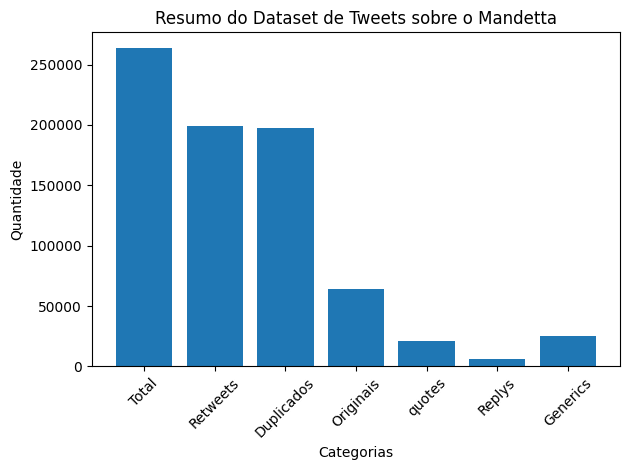

In [199]:
#Grafico resumindo:
total = num_tweets
retweets = num_rt
originais = num_tweets_or
duplicados_qtd = len(duplicados)
num_quotes = len(quotes)
num_replys = len(replys)
num_generics = len(generics)

labels = ["Total", "Retweets",  "Duplicados", "Originais", "quotes","Replys", "Generics"]
values = [total, retweets, duplicados_qtd, originais, num_quotes, num_replys, num_generics]

plt.figure()
plt.bar(labels, values)
plt.title("Resumo do Dataset de Tweets sobre o Mandetta")
plt.xlabel("Categorias")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [200]:
#definindo classes de tweets - 0 Generics, 1 replys, 2 quotes

def classification (tweet_bas):
  #tweet generico (is_reply e is_quote = false)
    if (tweet_bas['is_reply'] == False) & (tweet_bas["is_quote"] == False):
      return 0
  #tweet reply (is_reply = True e is_quote = False)
    elif (tweet_bas['is_reply'] == True) & (tweet_bas["is_quote"] == False):
      return 1
  #Caso contrario é quote (sobreposição de reply e quote é quote, considerado aqui)
    else:
      return 2
df["class"] = df.apply(classification, axis = 1) #normalmente 'aply' opera numa coluna inteiro (axis = 0). Para pegar todas, axis = 1

In [201]:
df

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text,class
0,1250828250370183168,57664074,"Para quem defendia o Mandetta , agora já sabe ...",Thu Apr 16 16:47:48 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,,0
1,1250828253260132353,882627779363254274,que merdaaaaaaaaaaaaaa tiraram o mandetta véi,Thu Apr 16 16:47:49 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,,0
2,1250827965899984907,1164652265271189510,#estudioi Mandetta estava usando Bolsonaro com...,Thu Apr 16 16:46:40 +0000 2020,1,1,True,961953706328641536,Thu Apr 16 16:47:49 +0000 2020,False,None,None,,False,None,None,None,,0
3,1250780916575866881,1138847289978626049,"Dória, Witzel, Alcolumbre, Rodrigo Maia, Mande...",Thu Apr 16 13:39:43 +0000 2020,751,2333,True,1656290641,Thu Apr 16 16:47:49 +0000 2020,False,None,None,,False,None,None,None,,0
4,1250828255806009345,1039608133587554311,"Demorou, não deveria ne ter sido nomeado mande...",Thu Apr 16 16:47:50 +0000 2020,0,0,False,None,None,False,None,None,,True,1250553117378088961,1523748277,conexaopolitica,"“O dia que ele [Mandetta] sair, eu saio junto ...",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263517,1251194009374031873,3145117967,Esse vídeo do Mandetta Abraçando e cantando ap...,Fri Apr 17 17:01:12 +0000 2020,0,0,False,None,None,False,None,None,,True,1251163075186552832,159728636,bruno_rteixeira,,1
263520,1251194013429968897,1185228960818499584,Mandetta se corrompeu a corrupção. VazaaaMandetta,Fri Apr 17 17:01:13 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,,0
263532,1251185636545085441,1022539297658953728,"O maior infectologista do mundo,Didier Raoult,...",Fri Apr 17 16:27:56 +0000 2020,5,18,True,715912036685840384,Fri Apr 17 17:01:16 +0000 2020,False,None,None,,False,None,None,None,,0
263535,1251194027124408328,52720920,"Pra eles pode tudo Gil, só não pode o Presiden...",Fri Apr 17 17:01:16 +0000 2020,0,0,False,None,None,False,None,None,,True,1251191015479926785,62290997,gilebruno,,1


In [202]:
df[df['tweet_id'].str.contains('1250533884296601603', na=False)]

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text,class


In [203]:
df[df['quoted_text'].str.contains('A maioria esmagadora dos brasileiros é contrária à demissão de Mandetta: 76,2% dos entrevistados discordam do afast', na=False)]

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text,class
83,1250828393530220550,879060203475533824,Não! eu acho que já era para ter sido demitido...,Thu Apr 16 16:48:22 +0000 2020,0,0,False,None,None,True,1250796092092006401,73745956,A maioria esmagadora dos brasileiros é contrár...,False,None,None,None,,2
405,1250828916023087104,507507057,não.esse ministro é político.falso,Thu Apr 16 16:50:27 +0000 2020,0,0,False,None,None,True,1250796092092006401,73745956,A maioria esmagadora dos brasileiros é contrár...,False,None,None,None,,2
470,1250828993080823813,1192707657125285888,"Não, não perguntaram para mim",Thu Apr 16 16:50:45 +0000 2020,0,0,False,None,None,True,1250796092092006401,73745956,A maioria esmagadora dos brasileiros é contrár...,False,None,None,None,,2
507,1250829052090474496,1091523352009850880,por estas e outras q vc justifica não ter nenh...,Thu Apr 16 16:50:59 +0000 2020,0,0,False,None,None,True,1250796092092006401,73745956,A maioria esmagadora dos brasileiros é contrár...,False,None,73745956,alvarodias_,,2
626,1250829238627942401,85116621,Não concordo com a pesquisa.,Thu Apr 16 16:51:44 +0000 2020,0,0,False,None,None,True,1250796092092006401,73745956,A maioria esmagadora dos brasileiros é contrár...,False,None,None,None,,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233995,1251140080359444483,1220006229927514114,A maioria esmagadora votou no único honesto do...,Fri Apr 17 13:26:54 +0000 2020,0,0,False,None,None,True,1250796092092006401,73745956,A maioria esmagadora dos brasileiros é contrár...,False,None,None,None,,2
241622,1251152328763138048,249964857,Tem fala mansa mas deixou todo mundo assustado...,Fri Apr 17 14:15:35 +0000 2020,0,0,False,None,None,True,1250796092092006401,73745956,A maioria esmagadora dos brasileiros é contrár...,False,None,None,None,,2
245468,1251158250856169473,1218852585823776768,"Data Faia revela em pesquisa q 99,99% dos víru...",Fri Apr 17 14:39:07 +0000 2020,0,0,False,None,None,True,1250796092092006401,73745956,A maioria esmagadora dos brasileiros é contrár...,False,None,None,None,,2
247092,1251161089645015041,1236039468584484865,Senador Álvaro tenho o maior respeito pelo seu...,Fri Apr 17 14:50:23 +0000 2020,0,0,False,None,None,True,1250796092092006401,73745956,A maioria esmagadora dos brasileiros é contrár...,False,None,None,None,,2


In [204]:
teste = df[df['quoted_text'].str.contains('A maioria esmagadora dos brasileiros é contrária à demissão de Mandetta: 76,2% dos entrevistados discordam do afast', na=False)]

In [205]:
texto = teste.iloc[0]['quoted_text']

In [206]:
texto

'A maioria esmagadora dos brasileiros é contrária à demissão de Mandetta: 76,2% dos entrevistados discordam do afastamento do ministro da Saúde, segundo pesquisa realizada pelo Atlas Político. Vc concorda com o resultado da pesquisa?   via'

In [207]:
teste = df[df['text'].str.contains('A maioria esmagadora dos brasileiros é contrária à demissão de Mandetta: 76,2% dos entrevistados discordam do afast', na=False)]

In [208]:
teste

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text,class
422,1250796092092006401,73745956,A maioria esmagadora dos brasileiros é contrár...,Thu Apr 16 14:40:01 +0000 2020,85,708,True,1241453383552204803,Thu Apr 16 16:50:32 +0000 2020,False,None,None,,False,None,None,None,,0


In [209]:
texto = teste.iloc[0]['text']

In [210]:
texto

'A maioria esmagadora dos brasileiros é contrária à demissão de Mandetta: 76,2% dos entrevistados discordam do afastamento do ministro da Saúde, segundo pesquisa realizada pelo Atlas Político. Vc concorda com o resultado da pesquisa?   via'

In [211]:
teste = df[df['text'].str.contains('A maioria esmagadora dos brasileiros é contrária à demissão de Mandetta', na=False)]

In [212]:
texto = teste.iloc[0]['text']

In [213]:
texto

'A maioria esmagadora dos brasileiros é contrária à demissão de Mandetta: 76,2% dos entrevistados discordam do afastamento do ministro da Saúde, segundo pesquisa realizada pelo Atlas Político. Vc concorda com o resultado da pesquisa?   via'

In [214]:
#classe 0
sum_class_0 = int ((df['class'] == 0).sum())
sum_class_0


25625

In [215]:
#Classe 1
sum_class_1 = int ((df['class'] == 1).sum())
sum_class_1

19732

In [216]:
#classe 2
sum_class_2 = int ((df['class'] == 2).sum())
sum_class_2

20879

In [217]:
#convertendo para csv
df.to_csv("mandetta.csv", index=False, encoding="utf-8")
files.download("mandetta.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>